# Proyecto Olist — Fundamentos Probabilísticos de ML
### Analista de experiencia del cliente en un marketplace

Este notebook aplica los 11 conceptos probabilísticos del curso al dataset 
de Olist (Brazilian E-Commerce), respondiendo preguntas concretas de negocio 
sobre satisfacción del cliente y comportamiento de vendedores.


## 0. Imports y carga de datos

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

pd.set_option("display.width", 100)
pd.set_option('display.max_columns', None)
np.set_printoptions(precision=4, suppress=True)

In [2]:
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

print(f"orders: {orders.shape}, items: {items.shape}, payments: {payments.shape}")
print(f"reviews: {reviews.shape}, products: {products.shape}")

orders: (99441, 8), items: (112650, 7), payments: (103886, 5)
reviews: (99224, 7), products: (32951, 9)


# 0.1 Limpieza y construcción del dataframe maestro

**Por qué un dataframe maestro:** Olist distribuye la información en 9 
archivos CSV relacionados por `order_id` (y por `product_id`/`seller_id` 
en cascada). Sin embargo, la mayoría de las preguntas de negocio de este 
análisis requieren cruzar información de al menos dos tablas — por 
ejemplo, "¿la entrega tardía se asocia con reseñas negativas?" necesita 
`retraso_dias` (calculado desde `orders`) junto con `review_score` 
(de `reviews`). Construir un único dataframe maestro, con una fila por 
pedido y todas las columnas relevantes ya unidas, evita repetir joins 
parciales e inconsistentes en cada uno de los 11 bloques de análisis, y 
deja una sola fuente de verdad verificable.


In [4]:
# ============================================================
# PASO 1: Convertir las columnas de fecha (llegan como texto/str) a datetime
# ============================================================ 
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# ============================================================
# PASO 2: Filtrar a pedidos completados y bien documentados
# ============================================================
# Excluimos:
# (a) pedidos que NO llegaron a estado 'delivered' (cancelados, en tránsito,
#     etc.) -- no tiene sentido medir "tiempo de entrega" de algo que nunca
#     se entregó.
# (b) los 8 casos inconsistentes detectados en la exploración: marcados como
#     'delivered' pero SIN fecha de entrega registrada (probable error de
#     captura de datos de Olist).
orders_delivered = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notnull())
].copy()  # .copy() evita el warning de pandas al modificar un subconjunto filtrado

# ============================================================
# PASO 3: Verificar cuántos registros quedaron y cuántos se excluyeron
# ============================================================
print(f"Pedidos originales: {len(orders):,}")
print(f"Pedidos delivered con fecha completa: {len(orders_delivered):,}")
print(f"Excluidos: {len(orders) - len(orders_delivered):,}")

Pedidos originales: 99,441
Pedidos delivered con fecha completa: 96,470
Excluidos: 2,971


**Decisiones de limpieza aplicadas:**
- Convertimos las columnas de fecha (texto) a tipo `datetime`, necesario 
  para calcular diferencias de tiempo.
- Filtramos a pedidos con `order_status == 'delivered'` y con 
  `order_delivered_customer_date` no nulo, excluyendo pedidos cancelados, 
  en tránsito, o con inconsistencias de registro (8 casos marcados como 
  entregados sin fecha de entrega) — el análisis de tiempos de entrega 
  solo tiene sentido sobre pedidos completados y bien documentados.
- Derivamos `tiempo_entrega_dias` (duración real del envío) y 
  `retraso_dias` (diferencia contra la fecha estimada; positivo = tardío).

### Derivación de columnas de tiempo

`orders` provee tres fechas crudas por pedido (compra, entrega estimada, 
entrega real), pero ninguna medida directa de duración o retraso. Como 
varias preguntas de negocio de este análisis (probabilidad condicional, 
ajuste de distribuciones, esperanza y varianza) requieren un valor 
numérico y no una fecha calendario, derivamos:

- **`tiempo_entrega_dias`**: duración real del envío (entrega real − compra).
- **`retraso_dias`**: diferencia contra la fecha prometida (entrega real − 
  entrega estimada). Positivo indica que el pedido llegó tarde; negativo, 
  que llegó antes de lo prometido.
- **`entrega_tardia`**: bandera binaria (`retraso_dias > 0`), que simplifica 
  su uso en cálculos de probabilidad condicional más adelante.

In [5]:
# ============================================================
# PASO 1: Calcular el tiempo real de entrega, en días
# ============================================================
orders_delivered['tiempo_entrega_dias'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_purchase_timestamp']
).dt.days

# ============================================================
# PASO 2: Calcular el retraso frente a lo prometido
# ============================================================
# > 0 = llegó tarde; < 0 = llegó antes de lo prometido
orders_delivered['retraso_dias'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_estimated_delivery_date']
).dt.days

# ============================================================
# PASO 3: Bandera binaria de entrega tardía
# ============================================================
orders_delivered['entrega_tardia'] = orders_delivered['retraso_dias'] > 0

orders_delivered[['tiempo_entrega_dias', 'retraso_dias', 'entrega_tardia']].describe()

,tiempo_entrega_dias,retraso_dias
count,96470.000000,96470.000000
mean,12.093604,-11.875889
std,9.551380,10.182105
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


In [6]:
orders_delivered['entrega_tardia'].value_counts(normalize=True)

entrega_tardia
False    0.932269
True     0.067731
Name: proportion, dtype: float64

## Joins hacia las tablas satélite

Unimos `orders_delivered` con las tablas necesarias para responder las 
preguntas de negocio de los 11 conceptos. Como `items` y `payments` pueden 
tener varias filas por pedido (múltiples productos o pagos fraccionados), 
los agregamos a nivel de pedido antes de unir, para mantener el dataframe 
maestro con exactamente una fila por pedido.

In [7]:
# ============================================================
# PASO 1: Un pedido puede tener varios ítems (productos) -> agregamos
# ============================================================
# Sumamos price y freight_value: nos interesa el TOTAL pagado por producto
# y por flete en el pedido completo, no ítem por ítem.
# Tomamos también la PRIMERA categoría de producto y el primer seller_id,
# como aproximación simple (la mayoría de pedidos tiene un solo producto).
items_agg = items.groupby('order_id').agg(
    price_total=('price', 'sum'),
    freight_total=('freight_value', 'sum'),
    n_items=('order_item_id', 'count'),
    product_id=('product_id', 'first'),
    seller_id=('seller_id', 'first')
).reset_index()

print(f"Pedidos únicos en items_agg: {len(items_agg):,}")
items_agg.head()

Pedidos únicos en items_agg: 98,666


,order_id,price_total,freight_total,n_items,product_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87


#### Agregación de `payments` a nivel de pedido

`payments` puede tener varias filas por `order_id` cuando el cliente pagó 
de forma fraccionada (ej. parte con tarjeta de crédito, parte con 
voucher). Como el dataframe maestro debe tener una única fila por pedido, 
resumimos cada columna según la operación que preserva su significado 
de negocio:

- **`payment_value_total`** (suma): `payment_value` registra el monto de 
  *cada transacción individual*, no el total del pedido. Sumar por 
  `order_id` reconstruye el monto real pagado en total — sin esto, 
  cualquier pedido pagado en varias transacciones se subestimaría en el 
  análisis, sesgando el "ticket promedio" hacia abajo sin razón real.

- **`payment_installments_max`** (máximo, no suma): las cuotas de 
  transacciones distintas no son aditivas — sumar "3 cuotas de tarjeta" 
  más "1 cuota de voucher" no representa nada real. Tomamos el máximo 
  como proxy del compromiso de pago más largo asumido por el cliente en 
  ese pedido, útil como señal de "nivel de financiamiento".

- **`payment_type` "principal"**: como el tipo de pago es una variable 
  categórica (no numérica), no se puede sumar ni promediar. Elegimos el 
  método asociado al *mayor monto pagado* dentro del pedido, como 
  aproximación del método de pago dominante — más representativo del 
  comportamiento real del cliente que tomar arbitrariamente "el primero 
  que aparece" en la tabla.

In [8]:
# ============================================================
# PASO 1: Un pedido puede tener varios pagos (ej. tarjeta + voucher)
# ============================================================
# Sumamos payment_value (el total pagado) y payment_installments (cuotas).
# Para payment_type, tomamos el de MAYOR valor pagado (el método "principal"),
# no simplemente el primero, para reflejar mejor cuál método domina el pago.
payment_type_principal = (
    payments.sort_values('payment_value', ascending=False)
    .drop_duplicates('order_id')[['order_id', 'payment_type']]
)

payments_agg = payments.groupby('order_id').agg(
    payment_value_total=('payment_value', 'sum'),
    payment_installments_max=('payment_installments', 'max')
).reset_index()

payments_agg = payments_agg.merge(payment_type_principal, on='order_id')

print(f"Pedidos únicos en payments_agg: {len(payments_agg):,}")
payments_agg.head()

Pedidos únicos en payments_agg: 99,440


,order_id,payment_value_total,payment_installments_max,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


### Agregación de `reviews` a nivel de pedido

Verificamos primero si `reviews` tiene más de una fila por pedido (poco 
común, pero posible si un cliente reseñó el mismo pedido más de una vez). 
De ser así, nos quedamos con la reseña más reciente por `order_id`, 
asumiendo que refleja la evaluación final del cliente.

In [9]:
# ============================================================
# PASO 1: Verificar si hay pedidos con más de una reseña
# ============================================================
duplicados_reviews = reviews['order_id'].duplicated().sum()
print(f"Pedidos con más de una reseña: {duplicados_reviews}")

# ============================================================
# PASO 2: Si existen duplicados, quedarnos con la más reciente
# ============================================================
# review_creation_date indica cuándo se creó la reseña; ordenamos
# descendente y tomamos la primera (más reciente) por pedido.
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])

reviews_agg = (
    reviews.sort_values('review_creation_date', ascending=False)
    .drop_duplicates('order_id')[['order_id', 'review_score', 'review_comment_message']]
)

print(f"Pedidos únicos en reviews_agg: {len(reviews_agg):,}")
reviews_agg.head()

Pedidos con más de una reseña: 551
Pedidos únicos en reviews_agg: 98,673


,order_id,review_score,review_comment_message
10764,bd2c2c3a4d59e68fb14a526745572883,4,NaN
55456,529a65336debb1c3e3327d7d67dc733d,5,NaN
96338,b0e9288a209f5ec50391c140dba4c91f,5,NaN
47024,d02b32c3bcfb76481817b2222b990e84,5,NaN
53698,8506571faf231af2bd4e43d1ba47dce8,5,NaN



### Merge final: construcción del dataframe maestro

Unimos `orders_delivered` (base, una fila por pedido) con `items_agg`, 
`payments_agg`, `reviews_agg` y la categoría de producto traducida. 
Usamos `how='left'` en todos los joins para no perder ningún pedido de 
la base aunque le falte información en alguna tabla satélite (por 
ejemplo, el pedido sin registro de pago que detectamos).

In [12]:
# ============================================================
# PASO 1: Partimos de orders_delivered (una fila por pedido, ya limpio)
# ============================================================
df_master = orders_delivered.copy()

# ============================================================
# PASO 2: Unimos items_agg (precio, flete, cantidad de ítems, producto/seller)
# ============================================================
df_master = df_master.merge(items_agg, on='order_id', how='left')

# ============================================================
# PASO 3: Unimos la categoría de producto (en portugués, sin traducir)
# ============================================================
df_master = df_master.merge(
    products[['product_id', 'product_category_name']],
    on='product_id', how='left'
)

# ============================================================
# PASO 4: Unimos payments_agg (monto total, cuotas máx, método principal)
# ============================================================
df_master = df_master.merge(payments_agg, on='order_id', how='left')

# ============================================================
# PASO 5: Unimos reviews_agg (calificación y comentario)
# ============================================================
df_master = df_master.merge(reviews_agg, on='order_id', how='left')

print(f"Dataframe maestro: {df_master.shape[0]:,} filas, {df_master.shape[1]} columnas")
df_master.isnull().sum()

Dataframe maestro: 96,470 filas, 22 columnas


order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   14
order_delivered_carrier_date         1
order_delivered_customer_date        0
order_estimated_delivery_date        0
tiempo_entrega_dias                  0
retraso_dias                         0
entrega_tardia                       0
price_total                          0
freight_total                        0
n_items                              0
product_id                           0
seller_id                            0
product_category_name             1359
payment_value_total                  1
payment_installments_max             1
payment_type                         1
review_score                       646
review_comment_message           57573
dtype: int64

### Tratamiento de nulos en el dataframe maestro

- `order_approved_at`, `order_delivered_carrier_date`, 
  `review_comment_message`: no se usan en ningún cálculo de los 11 
  conceptos, se dejan como están.
- `product_category_name` (1,359 nulos, ~1.4%): se recodifican como 
  `"unknown"` en vez de eliminarse, para no perder esos pedidos en 
  análisis que no dependen de la categoría.
- `payment_value_total`/`payment_installments_max`/`payment_type` 
  (1 nulo): un único pedido sin registro de pago; se excluye únicamente 
  en los bloques que usen estas columnas.
- `review_score` (646 nulos, ~0.7%): pedidos entregados sin reseña; se 
  excluyen únicamente en los bloques de análisis que dependan de la 
  calificación (probabilidad condicional, Bayes, entropía cruzada), no 
  del dataframe maestro completo.

In [13]:
df_master['product_category_name'] = df_master['product_category_name'].fillna('unknown')

print(f"Dataframe maestro final: {df_master.shape[0]:,} filas, {df_master.shape[1]} columnas")
df_master.head()

Dataframe maestro final: 96,470 filas, 22 columnas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tiempo_entrega_dias,retraso_dias,entrega_tardia,price_total,freight_total,n_items,product_id,seller_id,product_category_name,payment_value_total,payment_installments_max,payment_type,review_score,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,False,29.99,8.72,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,38.71,1.0,voucher,4.0,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,False,118.70,22.76,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,perfumaria,141.46,1.0,boleto,4.0,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,False,159.90,19.22,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,automotivo,179.12,3.0,credit_card,5.0,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,False,45.00,27.20,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,pet_shop,72.20,1.0,credit_card,5.0,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,False,19.90,8.72,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,papelaria,28.62,1.0,credit_card,5.0,NaN


# 1. Probabilidad condicional

**Pregunta de negocio:** ¿la entrega tardía cambia la probabilidad de 
que un cliente deje una reseña negativa (≤2 estrellas)?

Comparamos $P(\text{review\_score} \leq 2)$ (probabilidad marginal, sin 
condicionar en nada) con $P(\text{review\_score} \leq 2 \mid 
\text{entrega\_tardia})$ (probabilidad condicionada a que el pedido 
llegó tarde).

In [14]:
# ============================================================
# PASO 1: Filtrar solo pedidos con reseña registrada
# ============================================================
# Excluimos los 646 pedidos sin review_score -- no podemos calcular
# nada sobre la reseña de un pedido que nunca fue calificado.
df_reviewed = df_master[df_master['review_score'].notnull()].copy()

# ============================================================
# PASO 2: Crear una bandera de "reseña negativa" (<=2 estrellas)
# ============================================================
df_reviewed['resena_negativa'] = df_reviewed['review_score'] <= 2

# ============================================================
# PASO 3: Calcular la probabilidad marginal P(reseña negativa)
# ============================================================
# .mean() de una columna True/False da la proporción de True, es decir,
# la probabilidad empírica de que un pedido cualquiera tenga reseña negativa.
p_negativa_overall = df_reviewed['resena_negativa'].mean()

# ============================================================
# PASO 4: Calcular la probabilidad CONDICIONAL P(reseña negativa | tardío)
# ============================================================
# df.loc[condición, columna] selecciona solo las filas que cumplen la
# condición -- aquí, solo pedidos que llegaron tarde -- y calculamos
# qué proporción de ESOS tiene reseña negativa.
p_negativa_dado_tardio = df_reviewed.loc[
    df_reviewed['entrega_tardia'] == True, 'resena_negativa'
].mean()

# Repetimos para pedidos que llegaron a tiempo, como contraste
p_negativa_dado_atiempo = df_reviewed.loc[
    df_reviewed['entrega_tardia'] == False, 'resena_negativa'
].mean()

# ============================================================
# PASO 5: Imprimir y comparar
# ============================================================
print(f"P(reseña negativa) = {p_negativa_overall:.4f}")
print(f"P(reseña negativa | entrega tardía) = {p_negativa_dado_tardio:.4f}")
print(f"P(reseña negativa | entrega a tiempo) = {p_negativa_dado_atiempo:.4f}")
print(f"-> Una entrega tardía multiplica el riesgo de reseña negativa por "
      f"{p_negativa_dado_tardio / p_negativa_overall:.2f}x respecto al promedio.")

P(reseña negativa) = 0.1281
P(reseña negativa | entrega tardía) = 0.6240
P(reseña negativa | entrega a tiempo) = 0.0927
-> Una entrega tardía multiplica el riesgo de reseña negativa por 4.87x respecto al promedio.


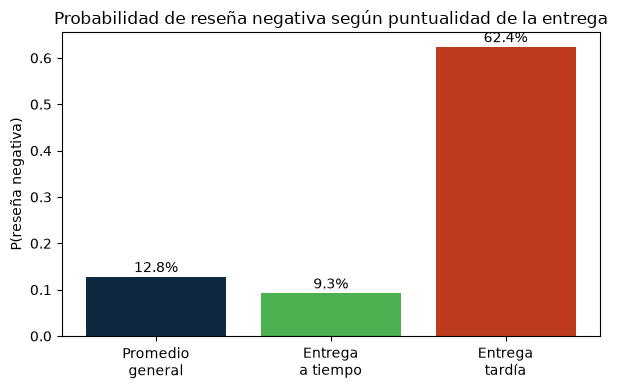

In [15]:
# ============================================================
# PASO 1: Preparar los datos para graficar
# ============================================================
categorias = ['Promedio\ngeneral', 'Entrega\na tiempo', 'Entrega\ntardía']
valores = [p_negativa_overall, p_negativa_dado_atiempo, p_negativa_dado_tardio]

# ============================================================
# PASO 2: Graficar barras
# ============================================================
fig = plt.figure(figsize=(6.2, 4))
plt.bar(categorias, valores, color=["#0E2841", "#4CAF50", "#BC3A1D"])

# ============================================================
# PASO 3: Escribir el porcentaje exacto encima de cada barra
# ============================================================
for i, v in enumerate(valores):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.ylabel("P(reseña negativa)")
plt.title("Probabilidad de reseña negativa según puntualidad de la entrega")
plt.tight_layout()
plt.show()

**Resultado:** una entrega tardía multiplica por **4.87x** la probabilidad 
de reseña negativa (62.4% vs. 12.8% general).

**Interpretación :** la puntualidad de entrega es, con amplio 
margen, el factor individual más asociado a la insatisfacción del cliente 
en Olist. Cualquier inversión en logística que reduzca el porcentaje de 
entregas tardías (actualmente 6.77% del total) tendría un impacto 
desproporcionadamente alto en la experiencia del cliente — más de la 
mitad de esos pedidos termina en reseña negativa.

# 2. Teorema de Bayes

**Pregunta de negocio:** dado que un pedido recibió una reseña negativa, 
¿qué tan probable es que haya llegado tarde? Esto es distinto a lo que 
calculamos en la Sección 1 — ahí sabíamos si el pedido llegó tarde y 
preguntábamos por la reseña; ahora partimos de la reseña (que ya 
conocemos apenas el cliente califica) y queremos inferir algo sobre la 
entrega.

$$P(\text{tardío} \mid \text{negativa}) = \frac{P(\text{negativa} \mid 
\text{tardío}) \cdot P(\text{tardío})}{P(\text{negativa})}$$

In [ ]:
# ============================================================
# PASO 1: Calcular las tres piezas que pide el Teorema de Bayes
# ============================================================
# P(evidencia | hipótesis): de los pedidos con reseña NEGATIVA, ¿qué
# proporción llegó tarde? Ya la teníamos calculada de forma inversa en
# la Sección 1 (p_negativa_dado_tardio), pero aquí necesitamos el
# "sentido contrario" -- lo calculamos directo:
p_tardio_given_negativa_directo = df_reviewed.loc[
    df_reviewed['resena_negativa'] == True, 'entrega_tardia'
].mean()

# El prior es la probabilidad de entrega tardía ANTES de conocer la reseña
p_tardio_prior = df_reviewed['entrega_tardia'].mean()

# P(evidencia): qué proporción de TODOS los pedidos tiene reseña negativa
p_negativa = df_reviewed['resena_negativa'].mean()

# P(negativa | tardío): ya la calculamos en la Sección 1
p_negativa_given_tardio = p_negativa_dado_tardio

# ============================================================
# PASO 2: Aplicar la fórmula de Bayes
# P(tardío|negativa) = P(negativa|tardío) * P(tardío) / P(negativa)
# ============================================================
p_tardio_given_negativa_bayes = (
    p_negativa_given_tardio * p_tardio_prior
) / p_negativa

# ============================================================
# PASO 3: Verificar contra el conteo directo (deben coincidir)
# ============================================================
print(f"Prior P(entrega tardía) = {p_tardio_prior:.4f}")
print(f"P(reseña negativa | tardío) = {p_negativa_given_tardio:.4f}")
print(f"P(reseña negativa) = {p_negativa:.4f}")
print(f"Posterior por Bayes: P(tardío | reseña negativa) = {p_tardio_given_negativa_bayes:.4f}")
print(f"Verificación directa (conteo): {p_tardio_given_negativa_directo:.4f}")

Prior P(entrega tardía) = 0.0666
P(reseña negativa | tardío) = 0.6240
P(reseña negativa) = 0.1281
Posterior por Bayes: P(tardío | reseña negativa) = 0.3245
Verificación directa (conteo): 0.3245


**Resultado:** P(entrega tardía | reseña negativa) = **32.45%** — casi 
5 veces el prior de 6.66%. Verificado con conteo directo (coincide 
exactamente: 0.3245).

**Interpretación de negocio:** invertir la probabilidad da a Olist una 
herramienta de diagnóstico retrospectivo: al ver una reseña negativa 
entrante, hay 1 en 3 probabilidades de que la causa raíz haya sido un 
retraso logístico. Esto permite priorizar investigaciones y distinguir 
entre reseñas negativas atribuibles a logística (32%) vs. otras causas 
como calidad de producto o servicio del vendedor (68% restante).

# 3-4. Verosimilitud (Likelihood) y Máxima Verosimilitud (MLE)

**Pregunta de negocio:** ¿qué distribución describe mejor el tiempo de 
entrega de los pedidos? Ajustamos por MLE dos distribuciones candidatas 
—Log-Normal y Gamma— y comparamos cuál se ajusta mejor usando la 
log-verosimilitud, para justificar cuál es más apropiada modelar el 
comportamiento logístico de Olist.

In [25]:
# ============================================================
# PASO 1: Verificar y filtrar valores no positivos (requisito de Log-Normal/Gamma)
# ============================================================
# Log-Normal y Gamma requieren x > 0 estrictamente, ya que su densidad
# depende de log(x), indefinido en x=0. Excluimos los 13 pedidos (0.013%
# del total) con tiempo_entrega_dias = 0 (entrega el mismo día de compra).
tiempos = df_master.loc[df_master['tiempo_entrega_dias'] > 0, 'tiempo_entrega_dias'].values
print(f"Observaciones usadas para el ajuste: {len(tiempos):,} (de {len(df_master):,} totales)")

# ============================================================
# PASO 2: Ajustar por Máxima Verosimilitud una distribución Log-Normal
# ============================================================
# floc=0 fija la ubicación en 0, ya que el tiempo de entrega no puede ser
# negativo -- es una restricción razonable para esta variable.
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(tiempos, floc=0)

# ============================================================
# PASO 3: Ajustar por Máxima Verosimilitud una distribución Gamma
# ============================================================
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(tiempos, floc=0)

# ============================================================
# PASO 4: Calcular la log-verosimilitud de cada ajuste
# ============================================================
# logpdf calcula el logaritmo de la densidad de cada dato bajo el modelo
# ajustado; sumamos todos para obtener la log-verosimilitud total.
# Un valor MENOS NEGATIVO (más cercano a 0) indica mejor ajuste.
loglik_ln = np.sum(stats.lognorm.logpdf(tiempos, shape_ln, loc_ln, scale_ln))
loglik_gamma = np.sum(stats.gamma.logpdf(tiempos, shape_gamma, loc_gamma, scale_gamma))

print(f"Log-Normal:  shape={shape_ln:.4f}, scale={scale_ln:.4f} | log-verosimilitud = {loglik_ln:.1f}")
print(f"Gamma:       shape={shape_gamma:.4f}, scale={scale_gamma:.4f} | log-verosimilitud = {loglik_gamma:.1f}")

if loglik_ln > loglik_gamma:
    print(f"\n-> La distribución Log-Normal ajusta mejor (log-verosimilitud más alta).")
else:
    print(f"\n-> La distribución Gamma ajusta mejor (log-verosimilitud más alta).")

Observaciones usadas para el ajuste: 96,457 (de 96,470 totales)
Log-Normal:  shape=0.7332, scale=9.4195 | log-verosimilitud = -323261.5
Gamma:       shape=2.1517, scale=5.6214 | log-verosimilitud = -323617.0

-> La distribución Log-Normal ajusta mejor (log-verosimilitud más alta).


### Nota sobre el ajuste de distribución

Se excluyen del ajuste MLE los pedidos con `tiempo_entrega_dias = 0` 
(entrega el mismo día de la compra, 13 casos, 0.013% del total), ya que 
las distribuciones Log-Normal y Gamma requieren valores estrictamente 
positivos (su densidad depende de `log(x)`, indefinido en x=0). Estos 
casos son válidos como entregas ultra-rápidas, pero representan una 
fracción mínima y no afectan la conclusión sobre qué distribución 
describe mejor el comportamiento general.

In [26]:
n_ceros = (df_master['tiempo_entrega_dias'] == 0).sum()
print(f"Pedidos con tiempo_entrega_dias = 0: {n_ceros}")
print(f"Porcentaje del total: {100 * n_ceros / len(df_master):.3f}%")

Pedidos con tiempo_entrega_dias = 0: 13
Porcentaje del total: 0.013%


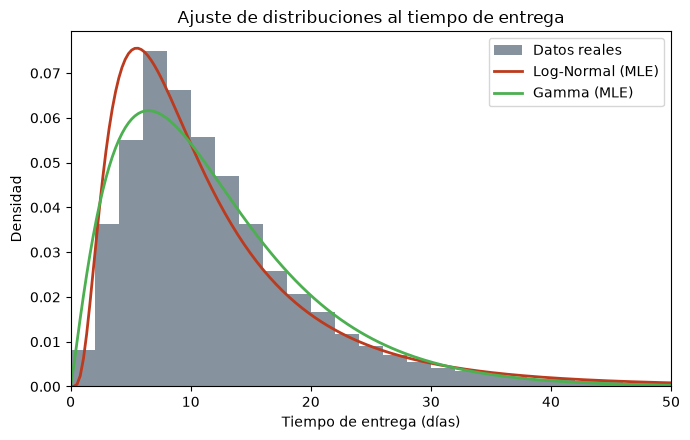

In [37]:
# ============================================================
# PASO 1: Definir bins de ancho FIJO (2 días), no cantidad fija
# ============================================================
# Esto evita que cambiar el rango visible (xlim) distorsione la altura
# de las barras -- el ancho de cada barra siempre representa "2 días",
# sin importar cuántos bins caben en el rango mostrado.
bin_width = 2
bins = np.arange(0, tiempos.max() + bin_width, bin_width)

fig = plt.figure(figsize=(7, 4.5))
plt.hist(tiempos, bins=bins, density=True, alpha=0.5, color="#0E2841", label="Datos reales")

x = np.linspace(0, 80, 300)
plt.plot(x, stats.lognorm.pdf(x, shape_ln, loc_ln, scale_ln),
         color="#BC3A1D", lw=2, label="Log-Normal (MLE)")
plt.plot(x, stats.gamma.pdf(x, shape_gamma, loc_gamma, scale_gamma),
         color="#4CAF50", lw=2, label="Gamma (MLE)")

plt.xlabel("Tiempo de entrega (días)")
plt.ylabel("Densidad")
plt.title("Ajuste de distribuciones al tiempo de entrega")
plt.xlim(0, 50)
plt.legend()
plt.tight_layout()
plt.show()

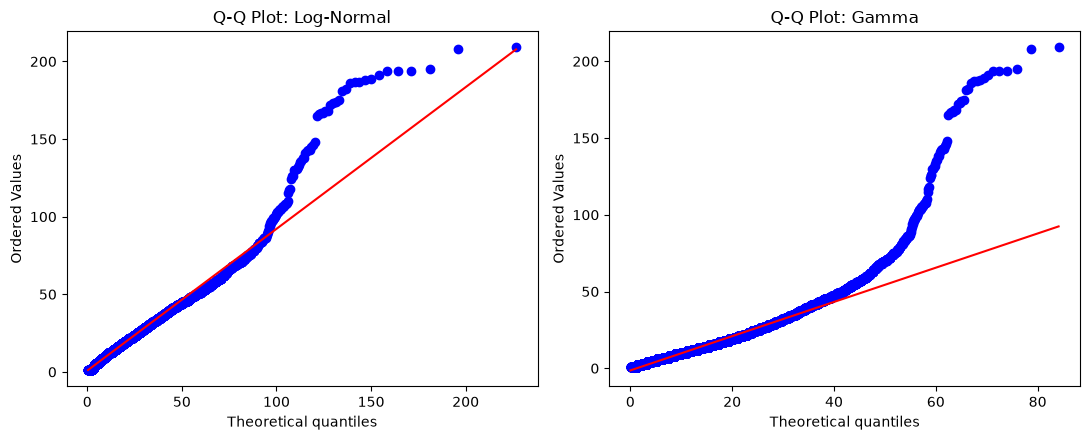

In [38]:
# ============================================================
# Q-Q plots: comparación más objetiva que el histograma
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

stats.probplot(tiempos, dist=stats.lognorm, sparams=(shape_ln, loc_ln, scale_ln), plot=axes[0])
axes[0].set_title("Q-Q Plot: Log-Normal")

stats.probplot(tiempos, dist=stats.gamma, sparams=(shape_gamma, loc_gamma, scale_gamma), plot=axes[1])
axes[1].set_title("Q-Q Plot: Gamma")

plt.tight_layout()
plt.show()

**Resultado:** la distribución Log-Normal ajusta mejor que la Gamma, 
tanto por log-verosimilitud (-323,261.5 vs. -323,617.0, una diferencia 
sustancial de ~355 unidades) como por el Q-Q plot, donde los puntos de 
la Log-Normal siguen más de cerca la diagonal teórica, especialmente en 
la cola derecha (retrasos extremos), frente a un desvío mayor en el 
ajuste Gamma en esa misma zona.

**Interpretación de negocio:** el tiempo de entrega sigue un patrón 
típico de procesos logísticos: la mayoría de los pedidos se concentra 
en un rango corto (6-15 días), pero existe una cola larga de retrasos 
extremos que la Log-Normal captura mejor que la Gamma. Una posible 
explicación es que los retrasos en cadenas logísticas multi-etapa 
tienden a comportarse de forma multiplicativa (un retraso en una etapa 
puede amplificar la probabilidad de retraso en la siguiente, en vez de 
sumarse linealmente) — consistente con por qué la Log-Normal, y no la 
Normal o Gamma, resulta el mejor ajuste. Para Olist, esto sugiere que 
prevenir retrasos tempranos en la cadena (ej. en el despacho del 
vendedor) puede tener un efecto desproporcionado en reducir los casos 
más extremos de retraso.

### ¿Qué significa que el tiempo de entrega sea Log-Normal?

Una variable sigue una distribución **Log-Normal** cuando su logaritmo 
sigue una distribución Normal. En otras palabras: si tomamos cada tiempo de entrega y le calculamos el logaritmo, esos logaritmos sí se comportan como una campana simétrica, aunque los tiempos originales no.

**¿Por qué pasa esto?** La Normal describe bien fenómenos donde muchos 
factores pequeños se **suman** de forma independiente (por ejemplo, la 
estatura de las personas: genética + nutrición + otros factores 
menores, sumados). La Log-Normal, en cambio, describe fenómenos donde 
los factores se **multiplican** entre sí en vez de sumarse — cada etapa 
actúa como un "porcentaje" sobre la anterior, no como una cantidad fija.

**En el contexto de Olist:** el tiempo total de entrega pasa por varias 
etapas encadenadas (preparación del vendedor → recolección por 
transportista → traslado → entrega final). Si el retraso en cada etapa 
tiende a *amplificar* la probabilidad de retraso en la siguiente 
(en vez de simplemente sumarle un número fijo de días), el resultado 
final se parece más a una Log-Normal que a una Normal. Por eso vemos en 
el histograma una forma asimétrica: la mayoría de los pedidos se 
concentra en un rango corto (6-15 días), pero hay una cola larga hacia 
la derecha de pedidos con retrasos desproporcionadamente grandes — 
justo el tipo de forma que produce este tipo de proceso multiplicativo.

# 5. Distribuciones paramétricas

**Pregunta de negocio:** ¿qué distribución teórica corresponde a cada 
tipo de variable del dataset? Justificar esto correctamente es la base 
para saber qué modelo probabilístico aplicar en análisis futuros (por 
ejemplo, simulaciones de riesgo, pruebas de hipótesis, o detección de 
anomalías).

- **`review_score`** (1 a 5 estrellas) → Categórica (5 resultados discretos, sin estructura binaria)
- **`entrega_tardia`** (sí/no) → Bernoulli (dos resultados posibles)
- **`payment_type`** (tarjeta, boleto, voucher, etc.) → Categórica
- **`tiempo_entrega_dias`** (continua) → Log-Normal (ya confirmado por MLE en la sección anterior)



In [39]:
# ============================================================
# PASO 1: entrega_tardia es un resultado binario -> Bernoulli
# ============================================================
# Su único parámetro p ya lo calculamos en el Bloque 2 (prior)
print(f"entrega_tardia -> Bernoulli(p={p_tardio_prior:.4f})")

# ============================================================
# PASO 2: review_score tiene 5 categorías ordenadas -> Categórica
# ============================================================
# value_counts(normalize=True) da la proporción de cada categoría,
# que son exactamente los parámetros de una distribución Categórica
print("\nreview_score -> Categórica sobre 5 valores:")
print(df_master['review_score'].value_counts(normalize=True).sort_index().round(4).to_string())

# ============================================================
# PASO 3: payment_type tiene varias categorías sin orden numérico -> Categórica
# ============================================================
print("\npayment_type -> Categórica:")
print(df_master['payment_type'].value_counts(normalize=True).round(4).to_string())

# ============================================================
# PASO 4: tiempo_entrega_dias -> Log-Normal (ya ajustada en Bloque 3-4)
# ============================================================
print(f"\ntiempo_entrega_dias -> Log-Normal(shape={shape_ln:.4f}, scale={scale_ln:.4f})")
print("(justificación completa y comparación contra Gamma en el Bloque 3-4)")

entrega_tardia -> Bernoulli(p=0.0666)

review_score -> Categórica sobre 5 valores:
review_score
1.0    0.0976
2.0    0.0305
3.0    0.0826
4.0    0.1972
5.0    0.5922

payment_type -> Categórica:
payment_type
credit_card    0.7548
boleto         0.1989
voucher        0.0309
debit_card     0.0154

tiempo_entrega_dias -> Log-Normal(shape=0.7332, scale=9.4195)
(justificación completa y comparación contra Gamma en el Bloque 3-4)


**Resultado:** las distribuciones confirman patrones esperables de un 
marketplace maduro — `review_score` está fuertemente sesgada hacia 
calificaciones positivas (78.9% con 4-5 estrellas), y `payment_type` 
está dominado por tarjeta de crédito (75.5%), consistente con patrones 
de consumo digital en Brasil.

**Interpretación de negocio:** que casi 4 de cada 5 reseñas sean 
positivas confirma que la experiencia general en Olist es buena — lo 
cual hace más notable el hallazgo del Bloque 1: el pequeño segmento de 
pedidos con entrega tardía (6.66% del total) concentra un riesgo 
desproporcionado de arrastrar esa satisfacción hacia abajo. La alta 
concentración en tarjeta de crédito (75.5%) también sugiere que 
cualquier fricción en ese método de pago específico tendría impacto 
amplio, al ser la opción mayoritaria de los clientes.

### Ajuste de distribución paramétrica: valor del pedido (`price_total`)

**Pregunta de negocio:** ¿qué distribución paramétrica describe mejor el 
valor de los pedidos en Olist? Esto es relevante para modelar el 
comportamiento de compra y detectar pedidos atípicamente altos o bajos. 
Ajustamos por MLE una distribución Log-Normal (esperable en variables de 
gasto, que suelen tener una cola larga de compras grandes) y la 
contrastamos visualmente con un histograma real.

Observaciones usadas: 96,470
Log-Normal ajustada: shape=0.9310, scale=84.8698

Log-verosimilitud Log-Normal: -558425.8
Log-verosimilitud Gamma:      -570318.5


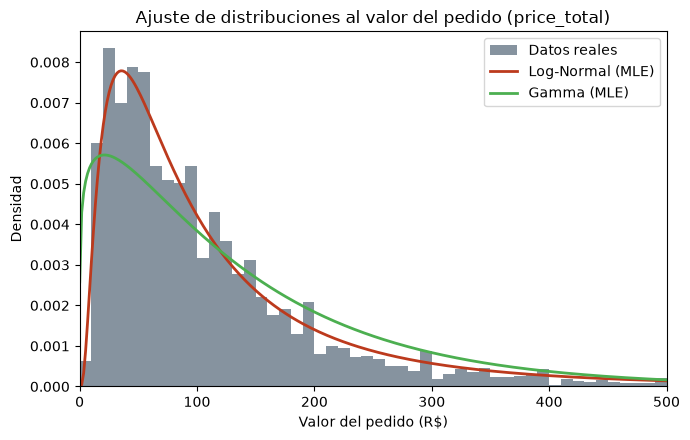

In [40]:
# ============================================================
# PASO 1: Extraer los valores de pedido válidos (positivos)
# ============================================================
precios = df_master.loc[df_master['price_total'] > 0, 'price_total'].values
print(f"Observaciones usadas: {len(precios):,}")

# ============================================================
# PASO 2: Ajustar por MLE una distribución Log-Normal
# ============================================================
shape_p, loc_p, scale_p = stats.lognorm.fit(precios, floc=0)
print(f"Log-Normal ajustada: shape={shape_p:.4f}, scale={scale_p:.4f}")

# ============================================================
# PASO 3: Ajustar también una Gamma, para tener contraste (mismo patrón
# que usamos con tiempo de entrega)
# ============================================================
shape_pg, loc_pg, scale_pg = stats.gamma.fit(precios, floc=0)

loglik_p_ln = np.sum(stats.lognorm.logpdf(precios, shape_p, loc_p, scale_p))
loglik_p_gamma = np.sum(stats.gamma.logpdf(precios, shape_pg, loc_pg, scale_pg))

print(f"\nLog-verosimilitud Log-Normal: {loglik_p_ln:.1f}")
print(f"Log-verosimilitud Gamma:      {loglik_p_gamma:.1f}")

# ============================================================
# PASO 4: Histograma + curvas ajustadas
# ============================================================
fig = plt.figure(figsize=(7, 4.5))
bin_width = 10
bins = np.arange(0, precios.max() + bin_width, bin_width)
plt.hist(precios, bins=bins, density=True, alpha=0.5, color="#0E2841", label="Datos reales")

x = np.linspace(0.1, 500, 300)
plt.plot(x, stats.lognorm.pdf(x, shape_p, loc_p, scale_p),
         color="#BC3A1D", lw=2, label="Log-Normal (MLE)")
plt.plot(x, stats.gamma.pdf(x, shape_pg, loc_pg, scale_pg),
         color="#4CAF50", lw=2, label="Gamma (MLE)")

plt.xlabel("Valor del pedido (R$)")
plt.ylabel("Densidad")
plt.title("Ajuste de distribuciones al valor del pedido (price_total)")
plt.xlim(0, 500)
plt.legend()
plt.tight_layout()
plt.show()

**Resultado:** la distribución Log-Normal ajusta considerablemente mejor 
que la Gamma para el valor del pedido (log-verosimilitud de -558,425.8 
vs. -570,318.5), una diferencia aún más marcada que la observada para el 
tiempo de entrega.

**Interpretación de negocio:** que el valor del pedido sea Log-Normal es 
un patrón clásico en variables de gasto: la mayoría de los clientes 
compra montos moderados, pero existe un segmento minoritario de compras 
de alto valor que genera una cola larga. Para Olist, esto significa que 
estrategias de pricing o promociones deberían pensarse en términos 
relativos (porcentajes de descuento) más que absolutos (montos fijos), 
ya que el "cliente típico" y el "cliente de alto valor" operan en 
escalas muy distintas.

# 6. Esperanza y Varianza

**Pregunta de negocio:** ¿qué categorías de producto tienen mayor 
variabilidad en el valor del pedido? Una categoría con alta varianza 
representa mayor incertidumbre para Olist al proyectar ingresos o 
planificar inventario — aunque el promedio sea similar a otra categoría, 
una mayor dispersión implica más riesgo.

In [43]:
# ============================================================
# PASO 1: Agrupar por categoría de producto y calcular Esperanza y Varianza
# ============================================================
# .mean() calcula la Esperanza empírica E[X]: el promedio de los pedidos
# de esa categoría.
# .var(ddof=1) calcula la Varianza muestral (ddof=1 usa n-1, la corrección
# estándar para que el estimador no esté sesgado).
# Filtramos categorías con al menos 30 pedidos, para evitar que categorías
# con muy pocos datos generen varianzas poco confiables.
stats_por_categoria = df_master.groupby('product_category_name')['price_total'].agg(
    esperanza='mean',
    varianza=lambda x: x.var(ddof=1),
    n_pedidos='count'
).query('n_pedidos >= 30')

# ============================================================
# PASO 2: Ordenar por varianza (mayor riesgo primero)
# ============================================================
top_varianza = stats_por_categoria.sort_values('varianza', ascending=False).head(10)

# ============================================================
# PASO 3: Agregar desviación estándar (misma unidad que el precio) y
# coeficiente de variación (CV = std/media), que permite comparar
# variabilidad RELATIVA entre categorías con precios muy distintos
# ============================================================
top_varianza['desv_estandar'] = np.sqrt(top_varianza['varianza'])
top_varianza['coef_variacion'] = top_varianza['desv_estandar'] / top_varianza['esperanza']

print(top_varianza[['esperanza', 'desv_estandar', 'coef_variacion', 'n_pedidos']].round(2).to_string())

                                    esperanza  desv_estandar  coef_variacion  n_pedidos
product_category_name                                                                  
telefonia_fixa                         261.30        1078.61            4.13        212
pcs                                   1234.63         731.78            0.59        176
portateis_casa_forno_e_cafe            647.08         621.39            0.96         72
agro_industria_e_comercio              398.68         604.15            1.52        177
eletrodomesticos_2                     477.01         532.55            1.12        226
eletroportateis                        300.87         502.98            1.67        606
artes                                  121.64         465.84            3.83        191
instrumentos_musicais                  303.56         464.54            1.53        607
construcao_ferramentas_seguranca       247.59         378.76            1.53        154
construcao_ferramentas_ferrament

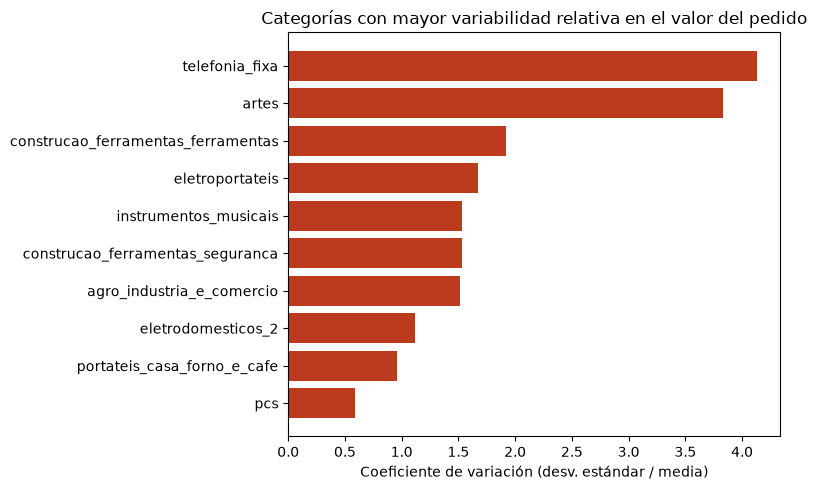

In [44]:
# ============================================================
# PASO 4: Graficar el coeficiente de variación (riesgo relativo)
# ============================================================
top_cv = top_varianza.sort_values('coef_variacion', ascending=False)

fig = plt.figure(figsize=(8, 5))
plt.barh(top_cv.index, top_cv['coef_variacion'], color="#BC3A1D")
plt.xlabel("Coeficiente de variación (desv. estándar / media)")
plt.title("Categorías con mayor variabilidad relativa en el valor del pedido")
plt.gca().invert_yaxis()  # la categoría con mayor CV arriba
plt.tight_layout()
plt.show()

**Resultado:** aunque `telefonia_fixa` no tiene ni el mayor promedio ni 
la mayor cantidad de pedidos, tiene el coeficiente de variación más alto 
(CV=4.13) — su desviación estándar es más de 4 veces su propio promedio, 
señal de que unos pocos pedidos extremadamente caros conviven con la 
mayoría de bajo valor dentro de esa misma categoría. `artes` (CV=3.83) 
muestra un patrón similar.

**Interpretación de negocio:** la varianza cruda favorece categorías con 
precios altos (`pcs`, `portateis_casa_forno_e_cafe`), pero el coeficiente 
de variación revela que `telefonia_fixa` y `artes` son las categorías de 
mayor **riesgo relativo** — su comportamiento de precio es el menos 
predecible en proporción a su propio promedio. Para Olist, esto sugiere 
revisar si estas categorías mezclan subtipos de producto muy distintos 
(ej. accesorios económicos vs. equipos profesionales) que ameritarían 
separarse en el catálogo para mejorar la predictibilidad de ingresos.

# 7. Independencia y Correlación

**Pregunta de negocio (parte 1):** ¿el método de pago está relacionado 
con la categoría de producto, o son independientes? Usamos una prueba 
chi-cuadrado sobre la tabla de contingencia.

**Pregunta de negocio (parte 2):** ¿existe correlación entre el tiempo 
de entrega y la calificación del pedido?

In [45]:
# ============================================================
# PASO 1: Construir la tabla de contingencia (conteos cruzados)
# ============================================================
# Para que la prueba sea manejable, usamos las 10 categorías con más
# pedidos (una tabla con las ~70 categorías totales sería difícil de
# interpretar y tendría celdas con muy pocos datos, debilitando la prueba).
top10_categorias = df_master['product_category_name'].value_counts().head(10).index
df_top10 = df_master[df_master['product_category_name'].isin(top10_categorias)]

contingency = pd.crosstab(df_top10['product_category_name'], df_top10['payment_type'])

# ============================================================
# PASO 2: Prueba de independencia chi-cuadrado
# ============================================================
# chi2_contingency compara los conteos observados contra los que se
# esperarían SI las dos variables fueran independientes.
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("Tabla de contingencia (top 10 categorías x método de pago):")
print(contingency)
print(f"\nChi-cuadrado = {chi2:.2f}, p-value = {p_value:.6f}, gl = {dof}")

if p_value < 0.05:
    print("-> p-value < 0.05: se rechaza independencia; método de pago y categoría están relacionados.")
else:
    print("-> p-value >= 0.05: no hay evidencia suficiente para rechazar independencia.")

Tabla de contingencia (top 10 categorías x método de pago):
payment_type            boleto  credit_card  debit_card  voucher
product_category_name                                           
automotivo                 767         2845          66      114
beleza_saude              1653         6626         138      190
brinquedos                 659         2965          43      111
cama_mesa_banho           1568         7150         117      332
esporte_lazer             1545         5619         115      211
informatica_acessorios    1667         4528         137      168
moveis_decoracao          1299         4628          77      209
relogios_presentes         897         4379          56      138
telefonia                  921         2958          75      122
utilidades_domesticas     1010         4349          99      230

Chi-cuadrado = 392.39, p-value = 0.000000, gl = 27
-> p-value < 0.05: se rechaza independencia; método de pago y categoría están relacionados.


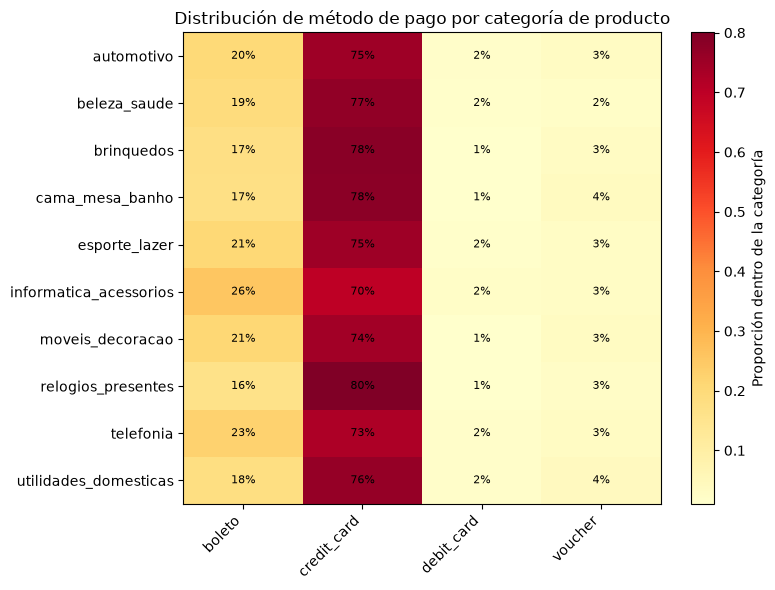

In [46]:
# ============================================================
# PASO 1: Convertir la tabla de contingencia a PROPORCIONES por fila
# ============================================================
# Normalizamos por fila (cada categoría de producto) para comparar el
# "perfil" de métodos de pago de cada categoría, sin que el tamaño
# absoluto de cada categoría distorsione la comparación visual.
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0)

# ============================================================
# PASO 2: Graficar como mapa de calor
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(contingency_pct.values, cmap='YlOrRd', aspect='auto')

# Etiquetas de ejes
ax.set_xticks(range(len(contingency_pct.columns)))
ax.set_xticklabels(contingency_pct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(contingency_pct.index)))
ax.set_yticklabels(contingency_pct.index)

# Escribir el porcentaje dentro de cada celda
for i in range(len(contingency_pct.index)):
    for j in range(len(contingency_pct.columns)):
        ax.text(j, i, f"{contingency_pct.values[i,j]:.0%}",
                ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, label="Proporción dentro de la categoría")
plt.title("Distribución de método de pago por categoría de producto")
plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# PASO 1: Calcular los residuos estandarizados
# ============================================================
# El residuo estandarizado = (observado - esperado) / raíz(esperado).
# Un valor > +2 o < -2 indica que esa celda específica se aparta de
# forma notable de lo que esperarías bajo independencia -- es la forma
# más objetiva de ver DÓNDE está la relación, no solo SI existe.
residuals = (contingency - expected) / np.sqrt(expected)

print("Tabla de conteos observados:")
print(contingency.to_string())

print("\nTabla de conteos esperados (si fueran independientes):")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1).to_string())

print("\nResiduos estandarizados (>+2 o <-2 = desviación notable):")
print(residuals.round(2).to_string())

# ============================================================
# PASO 2: Señalar automáticamente las celdas más notables
# ============================================================
print("\nCeldas con mayor desviación (|residuo| > 2):")
for cat in residuals.index:
    for pago in residuals.columns:
        r = residuals.loc[cat, pago]
        if abs(r) > 2:
            direccion = "MÁS" if r > 0 else "MENOS"
            print(f"  {cat} x {pago}: residuo={r:.2f} ({direccion} de lo esperado)")

Tabla de conteos observados:
payment_type            boleto  credit_card  debit_card  voucher
product_category_name                                           
automotivo                 767         2845          66      114
beleza_saude              1653         6626         138      190
brinquedos                 659         2965          43      111
cama_mesa_banho           1568         7150         117      332
esporte_lazer             1545         5619         115      211
informatica_acessorios    1667         4528         137      168
moveis_decoracao          1299         4628          77      209
relogios_presentes         897         4379          56      138
telefonia                  921         2958          75      122
utilidades_domesticas     1010         4349          99      230

Tabla de conteos esperados (si fueran independientes):
payment_type            boleto  credit_card  debit_card  voucher
product_category_name                                           
autom

In [47]:
# ============================================================
# PASO 3: Correlación entre tiempo de entrega y calificación (numéricas)
# ============================================================
# np.corrcoef requiere que ambas variables sean numéricas y sin nulos.
# Usamos df_reviewed (ya filtrado a pedidos con review_score) del Bloque 1.
corr_matrix = np.corrcoef(
    df_reviewed['tiempo_entrega_dias'],
    df_reviewed['review_score']
)
corr_tiempo_review = corr_matrix[0, 1]

print(f"Correlación (tiempo_entrega_dias, review_score) = {corr_tiempo_review:.4f}")

Correlación (tiempo_entrega_dias, review_score) = -0.3339


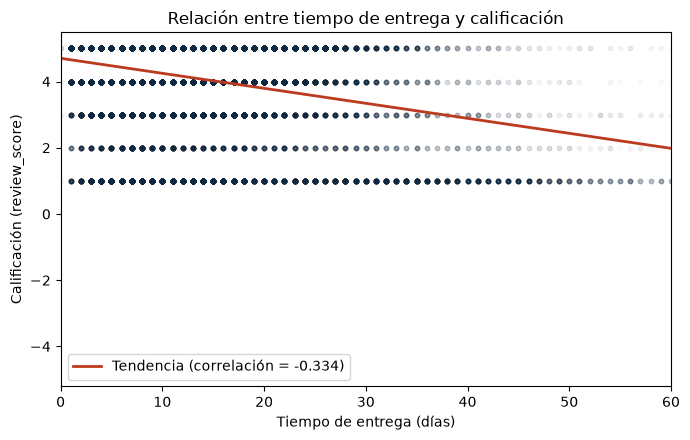

In [48]:
# ============================================================
# PASO 1: Scatter plot con línea de tendencia
# ============================================================
fig = plt.figure(figsize=(7, 4.5))

# alpha bajo porque hay ~96,000 puntos -- sin transparencia se vería
# una mancha sólida imposible de interpretar
plt.scatter(df_reviewed['tiempo_entrega_dias'], df_reviewed['review_score'],
            alpha=0.02, color="#0E2841", s=10)

# ============================================================
# PASO 2: Agregar línea de tendencia (regresión lineal simple)
# ============================================================
z = np.polyfit(df_reviewed['tiempo_entrega_dias'], df_reviewed['review_score'], 1)
x_line = np.linspace(df_reviewed['tiempo_entrega_dias'].min(),
                      df_reviewed['tiempo_entrega_dias'].max(), 100)
plt.plot(x_line, np.polyval(z, x_line), color="#BC3A1D", lw=2,
         label=f"Tendencia (correlación = {corr_tiempo_review:.3f})")

plt.xlabel("Tiempo de entrega (días)")
plt.ylabel("Calificación (review_score)")
plt.title("Relación entre tiempo de entrega y calificación")
plt.xlim(0, 60)
plt.legend()
plt.tight_layout()
plt.show()

**Resultado (evidencia detallada):** los residuos estandarizados 
confirman que la relación no es ruido estadístico disperso, sino que se 
concentra en patrones interpretables. El caso más extremo es 
`informatica_acessorios`, que usa boleto muchísimo más de lo esperado 
(residuo=10.76) y tarjeta de crédito notablemente menos (-5.65) — un 
perfil de pago casi opuesto al de `relogios_presentes`, que se inclina 
hacia tarjeta de crédito (+3.65) y evita boleto (-5.53).

**Interpretación de negocio:** estos patrones sugieren perfiles de 
cliente distintos según categoría — compradores de accesorios de 
informática prefieren pagos sin financiamiento (boleto/débito), mientras 
que compradores de relojes/regalos y artículos para el hogar financian 
más con tarjeta. Esto es información accionable: Olist podría ofrecer 
opciones de pago diferenciadas por categoría (ej. destacar boleto en 
informática, promociones de cuotas sin interés en regalos) en vez de una 
política de pago uniforme.Por 
otro lado, la correlación entre tiempo de entrega y calificación es 
**-0.3339**, moderada y negativa, confirmando con una segunda técnica lo 
observado en el Bloque 1: a mayor tiempo de entrega, menor calificación.

## 8. Prior y Posterior

**Pregunta de negocio:** cuando un vendedor es nuevo en Olist y aún no 
tiene historial, ¿cuál es la mejor estimación de que sea "confiable" 
(genere reseñas positivas)? Partimos de un prior poblacional (la tasa 
general de la plataforma) y mostramos cómo se actualiza ese posterior a 
medida que el vendedor acumula ventas — ilustrando el mecanismo de forma 
genérica, aplicable a cualquier vendedor nuevo, no a un caso particular.

In [58]:
# ============================================================
# PASO 1: Definir "reseña positiva" y calcular el prior poblacional
# ============================================================
# El prior es la tasa de reseñas positivas de TODA la plataforma -- la
# mejor estimación disponible para CUALQUIER vendedor nuevo del que aún
# no sabemos nada.
df_reviewed['resena_positiva'] = df_reviewed['review_score'] >= 4
prior_positiva = df_reviewed['resena_positiva'].mean()

print(f"Prior poblacional: P(reseña positiva) = {prior_positiva:.4f}")

Prior poblacional: P(reseña positiva) = 0.7893


In [60]:
# ============================================================
# PASO 1: Representar el prior como una distribución Beta
# ============================================================
# La Beta es el "conjugado natural" de una proporción tipo Bernoulli:
# alpha representa "éxitos" acumulados, beta representa "fracasos"
# acumulados. Elegimos alpha_0, beta_0 de forma que su proporción
# reproduzca el prior poblacional (78.93%), con un peso total de 10
# pseudo-observaciones -- representa "cuánta confianza" le damos al
# prior antes de ver evidencia real.
alpha_0 = prior_positiva * 10
beta_0 = (1 - prior_positiva) * 10

# ============================================================
# PASO 2: Simular una secuencia GENÉRICA de evidencia (ventas hipotéticas)
# ============================================================
# Esta secuencia no pertenece a ningún vendedor real -- ilustra el
# mecanismo de actualización para CUALQUIER vendedor nuevo que reciba
# este patrón de reseñas: 4 positivas seguidas de 1 negativa.
secuencia_ventas = [True, True, True, True, False]

alpha, beta = alpha_0, beta_0
posteriors = [alpha / (alpha + beta)]  # "paso 0": el prior puro

for i, es_positiva in enumerate(secuencia_ventas, start=1):
    if es_positiva:
        alpha += 1
    else:
        beta += 1
    posterior_actual = alpha / (alpha + beta)
    posteriors.append(posterior_actual)
    resultado = "positiva" if es_positiva else "negativa"
    print(f"Venta {i} ({resultado}): posterior = {posterior_actual:.4f}")

print(f"\nPrior inicial (sin evidencia): {posteriors[0]:.4f}")
print(f"Posterior final (tras {len(secuencia_ventas)} ventas): {posteriors[-1]:.4f}")

Venta 1 (positiva): posterior = 0.8085
Venta 2 (positiva): posterior = 0.8244
Venta 3 (positiva): posterior = 0.8379
Venta 4 (positiva): posterior = 0.8495
Venta 5 (negativa): posterior = 0.7929

Prior inicial (sin evidencia): 0.7893
Posterior final (tras 5 ventas): 0.7929


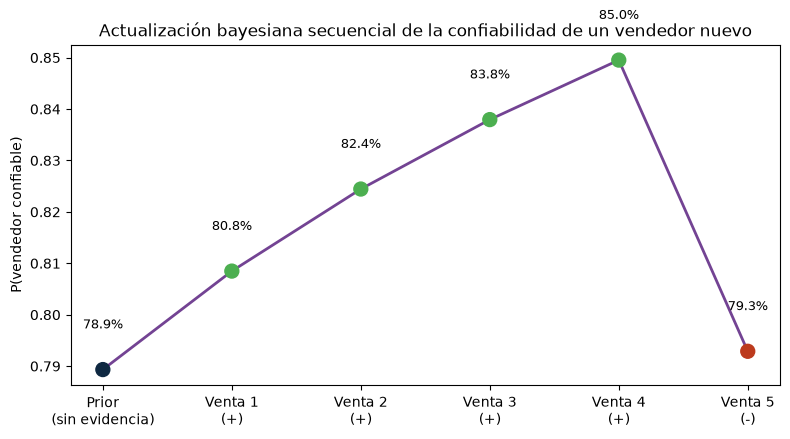

In [62]:
# ============================================================
# PASO 1: Graficar la evolución del posterior paso a paso
# ============================================================
etapas = ['Prior\n(sin evidencia)'] + [f'Venta {i}\n({"+" if v else "-"})' 
                                        for i, v in enumerate(secuencia_ventas, start=1)]

fig = plt.figure(figsize=(8, 4.5))
colores = ["#0E2841"] + ["#4CAF50" if v else "#BC3A1D" for v in secuencia_ventas]
plt.plot(range(len(posteriors)), posteriors, marker='o', color="#734393", lw=2, zorder=1)
plt.scatter(range(len(posteriors)), posteriors, color=colores, s=100, zorder=2)

for i, v in enumerate(posteriors):
    plt.text(i, v + 0.008, f"{v:.1%}", ha="center", fontsize=9)

plt.xticks(range(len(etapas)), etapas)
plt.ylabel("P(vendedor confiable)")
plt.title("Actualización bayesiana secuencial de la confiabilidad de un vendedor nuevo")
plt.tight_layout()
plt.show()

**Resultado:** partiendo del prior poblacional (78.93%), cuatro ventas 
positivas consecutivas elevan la estimación de confiabilidad hasta 
84.95%, pero una sola venta negativa la hace retroceder casi por 
completo (79.29%) — muy cerca del prior original.

**Interpretación de negocio:** el enfoque bayesiano evita dos errores 
comunes al evaluar vendedores nuevos: (1) sobreestimar la confiabilidad 
de un vendedor con pocas ventas todas positivas (el posterior sube, pero 
de forma moderada, no dispara a 100%), y (2) castigar desproporcionadamente 
a un vendedor por una sola reseña negativa temprana (el posterior no se 
desploma, solo regresa cerca del promedio poblacional). Esto es 
preferible a decisiones basadas en umbrales rígidos (ej. "suspender tras 
1 reseña negativa"), que penalizarían casos que estadísticamente son 
totalmente normales incluso para un buen vendedor.

# 9. Entropía

**Pregunta de negocio:** ¿qué tan diverso o concentrado es el catálogo 
de Olist en términos de categorías de producto vendidas? Una entropía 
alta indica un catálogo muy diverso (ventas repartidas entre muchas 
categorías); una entropía baja indica concentración en pocas categorías 
dominantes.

In [63]:
# ============================================================
# PASO 1: Definir la función de entropía de Shannon en bits
# ============================================================
def entropy_bits(p):
    p = np.array(p, dtype=float)
    p = p[p > 0]  # descartamos probabilidades de 0 (log(0) no está
                  # definido, y un evento imposible no aporta "sorpresa")
    return -np.sum(p * np.log2(p))  # fórmula de Shannon: -sum( p * log2(p) )

# ============================================================
# PASO 2: Calcular la distribución de probabilidad de las categorías
# ============================================================
# value_counts(normalize=True) da la proporción de pedidos en cada
# categoría -- eso es exactamente la distribución de probabilidad que
# necesita la fórmula de entropía.
dist_categorias = df_master['product_category_name'].value_counts(normalize=True)
n_categorias = len(dist_categorias)

h_categorias = entropy_bits(dist_categorias.values)

# ============================================================
# PASO 3: Comparar contra el máximo teórico (si todas las categorías
# fueran igual de frecuentes -- máxima diversidad posible)
# ============================================================
h_maximo = np.log2(n_categorias)

print(f"Número de categorías distintas: {n_categorias}")
print(f"H(categoría de producto) = {h_categorias:.4f} bits")
print(f"Máximo teórico (si todas fueran igual de frecuentes) = {h_maximo:.4f} bits")
print(f"Razón H/H_max = {h_categorias / h_maximo:.4f} ({h_categorias/h_maximo:.1%} del máximo posible)")

Número de categorías distintas: 74
H(categoría de producto) = 4.7662 bits
Máximo teórico (si todas fueran igual de frecuentes) = 6.2095 bits
Razón H/H_max = 0.7676 (76.8% del máximo posible)


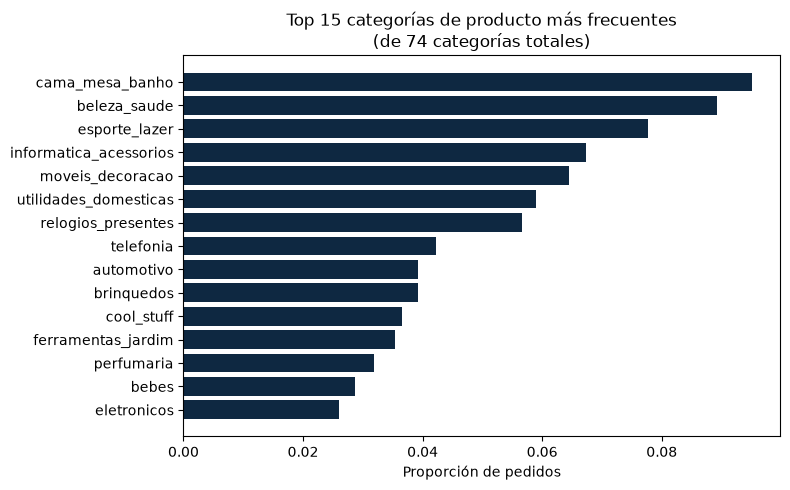

Las 5 categorías más vendidas concentran el 39.4% de los pedidos
Las 10 categorías más vendidas concentran el 63.0% de los pedidos


In [64]:
# ============================================================
# PASO 1: Graficar las 15 categorías más frecuentes
# ============================================================
top15 = dist_categorias.head(15)

fig = plt.figure(figsize=(8, 5))
plt.barh(top15.index, top15.values, color="#0E2841")
plt.xlabel("Proporción de pedidos")
plt.title(f"Top 15 categorías de producto más frecuentes\n(de {n_categorias} categorías totales)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================
# PASO 2: Cuánto concentran las top 5 y top 10 categorías
# ============================================================
concentracion_top5 = dist_categorias.head(5).sum()
concentracion_top10 = dist_categorias.head(10).sum()
print(f"Las 5 categorías más vendidas concentran el {concentracion_top5:.1%} de los pedidos")
print(f"Las 10 categorías más vendidas concentran el {concentracion_top10:.1%} de los pedidos")

**Resultado:** el catálogo de Olist tiene una entropía de 4.77 bits, 
equivalente al 76.8% del máximo teórico (si las 74 categorías fueran 
igual de frecuentes). Las 5 categorías más vendidas (`cama_mesa_banho`, 
`beleza_saude`, `esporte_lazer`, `informatica_acessorios`, 
`moveis_decoracao`) concentran el 39.4% de los pedidos, y las 10 
principales concentran el 63.0% — es decir, más de 6 de cada 10 pedidos 
provienen de solo el 13.5% de las categorías del catálogo (10 de 74).

**Interpretación de negocio:** Olist opera con un catálogo moderadamente 
diverso, no dominado por una sola categoría, pero con una concentración 
significativa: la mitad de las ventas dependen de apenas 7 categorías 
(según la curva acumulada, ~50% se alcanza alrededor de la séptima). 
Esto tiene dos implicaciones prácticas: (1) cualquier interrupción 
operativa o problema logístico en las categorías top 10 (hogar, belleza, 
deportes, tecnología, muebles) tendría impacto desproporcionado sobre el 
volumen total de la plataforma, y (2) las 64 categorías restantes 
(el otro 86.5% del catálogo) representan solo 37% de los pedidos, 
sugiriendo una "cola larga" de nicho que podría explorarse para 
diversificar el riesgo de concentración.

# 10. Entropía cruzada

**Pregunta de negocio:** ¿pueden las variables disponibles (tiempo de 
entrega, precio, categoría, método de pago) predecir si un cliente 
dejará una reseña positiva o negativa? Entrenamos una regresión 
logística y medimos su entropía cruzada (log loss), comparándola contra 
la entropía de la variable objetivo sola — si el modelo reduce la 
incertidumbre respecto a simplemente "adivinar" con la tasa base, 
confirma que las variables sí aportan información predictiva real.

In [66]:
# ============================================================
# PASO 1: Preparar variables predictoras (X) y variable objetivo (y)
# ============================================================
# Usamos df_reviewed (ya filtrado a pedidos con reseña) y seleccionamos
# variables disponibles ANTES de conocer la reseña -- es decir, señales
# que Olist tendría en el momento de despachar el pedido, no después.
features = df_reviewed[[
    'tiempo_entrega_dias', 'retraso_dias', 'price_total', 'freight_total',
    'payment_type', 'product_category_name'
]].copy()

# get_dummies convierte las columnas categóricas en columnas 0/1
# (one-hot encoding), porque la regresión logística necesita números.
# Para product_category_name, usamos solo las top 10 categorías (el resto
# se agrupa como "otras") para no generar 74 columnas dummy.
top10_cats = df_reviewed['product_category_name'].value_counts().head(10).index
features['product_category_name'] = features['product_category_name'].where(
    features['product_category_name'].isin(top10_cats), 'otras'
)

X = pd.get_dummies(features, drop_first=True)
y = df_reviewed['resena_positiva'].astype(int)

# ============================================================
# PASO 2: Separar entrenamiento y prueba, manteniendo la proporción
# de clases (stratify) ya que están algo desbalanceadas (78.9% vs 21.1%)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas, {X_train.shape[1]} columnas")
print(f"Prueba: {X_test.shape[0]:,} filas")

# ============================================================
# PASO 3: Entrenar el clasificador
# ============================================================
# LogisticRegression.fit() ajusta sus parámetros MINIMIZANDO exactamente
# la entropía cruzada entre las etiquetas reales y las probabilidades
# predichas -- mismo concepto de Máxima Verosimilitud del Bloque 3-4,
# aplicado a un modelo con muchas variables en vez de una Gaussiana simple.
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# ============================================================
# PASO 4: Medir la entropía cruzada (log loss) en train y test
# ============================================================
ce_train = log_loss(y_train, clf.predict_proba(X_train)[:, 1])
ce_test = log_loss(y_test, clf.predict_proba(X_test)[:, 1])

print(f"\nEntropía cruzada (log loss) en entrenamiento = {ce_train:.4f} nats")
print(f"Entropía cruzada (log loss) en prueba = {ce_test:.4f} nats")

# ============================================================
# PASO 5: Comparar contra la entropía de la variable objetivo sola
# ============================================================
h_resena = entropy_bits([prior_positiva, 1 - prior_positiva])
h_resena_nats = h_resena * np.log(2)  # convertir bits a nats
print(f"\nH(reseña positiva) en nats = {h_resena_nats:.4f} -> punto de referencia sin modelo")

Entrenamiento: 71,868 filas, 17 columnas
Prueba: 23,956 filas

Entropía cruzada (log loss) en entrenamiento = 0.4700 nats
Entropía cruzada (log loss) en prueba = 0.4702 nats

H(reseña positiva) en nats = 0.5148 -> punto de referencia sin modelo


### Conceptos clave: entropía cruzada, regresión logística y nats

**Entropía cruzada:** mide qué tan "sorprendido" queda un modelo, en 
promedio, al comparar la probabilidad que predijo contra lo que 
realmente ocurrió. Si el modelo predice 95% de probabilidad de reseña 
positiva y efectivamente lo es, la sorpresa (y la penalización) es baja; 
si predice 95% y resulta negativa, la sorpresa es alta. Un valor más 
bajo de entropía cruzada indica un modelo mejor calibrado con la 
realidad.

**Por qué regresión logística:** este modelo no solo predice una 
respuesta binaria (sí/no), sino una probabilidad continua entre 0 y 1. 
Más importante aún: sus parámetros se ajustan internamente 
**minimizando exactamente la entropía cruzada** — es su función de 
pérdida nativa, el mismo principio de Máxima Verosimilitud del Bloque 
3-4, aplicado ahora a un modelo con múltiples variables predictoras en 
vez de una sola distribución.

**Nats vs. bits:** en el Bloque 9 medimos la entropía en *bits* 
(logaritmo base 2). La función `log_loss` de scikit-learn usa en cambio 
*logaritmo natural* (base e), y a esa unidad se le llama **nats**. Es el 
mismo concepto de incertidumbre, solo con una "vara de medir" distinta — 
por eso convertimos la entropía de la Sección 9 a nats (multiplicando 
por `log(2)`) antes de compararla contra el resultado del modelo.

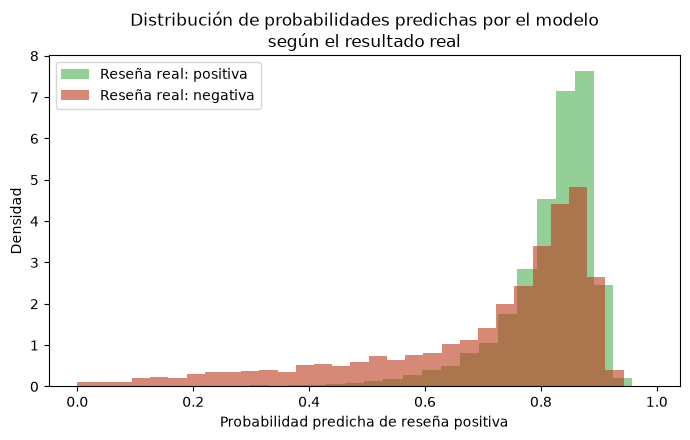

In [67]:
# ============================================================
# Gráfico: distribución de probabilidades predichas, separadas
# por si la reseña realmente fue positiva o negativa
# ============================================================
probs_test = clf.predict_proba(X_test)[:, 1]

fig = plt.figure(figsize=(7, 4.5))
plt.hist(probs_test[y_test == 1], bins=30, alpha=0.6, color="#4CAF50",
         label="Reseña real: positiva", density=True)
plt.hist(probs_test[y_test == 0], bins=30, alpha=0.6, color="#BC3A1D",
         label="Reseña real: negativa", density=True)

plt.xlabel("Probabilidad predicha de reseña positiva")
plt.ylabel("Densidad")
plt.title("Distribución de probabilidades predichas por el modelo\nsegún el resultado real")
plt.legend()
plt.tight_layout()
plt.show()

**Resultado:** la entropía cruzada del modelo (0.4700 nats en 
entrenamiento, 0.4702 en prueba) es menor que la entropía de la variable 
objetivo sola (0.5148 nats), y el resultado casi idéntico entre 
entrenamiento y prueba confirma que el modelo generaliza bien, sin 
sobreajuste. Sin embargo, el gráfico de distribución de probabilidades 
muestra que el modelo distingue de forma limitada: incluso las reseñas 
realmente negativas se concentran mayoritariamente hacia probabilidades 
altas de "positiva" (aunque con una cola más ancha hacia la izquierda 
que la clase positiva), reflejando una superposición considerable entre 
ambas clases.

**Interpretación de negocio:** las variables disponibles en el momento 
del despacho (tiempo de entrega, precio, flete, método de pago, 
categoría) aportan información real —el modelo sí reduce la 
incertidumbre respecto a adivinar con la tasa base—, pero está lejos de 
ser un predictor confiable caso por caso: la mayoría de los pedidos, 
incluso los que terminan en reseña negativa, reciben una probabilidad 
predicha alta de satisfacción. Esto es coherente con que la satisfacción 
del cliente depende en gran medida de factores que el dataset no 
captura (calidad percibida del producto, atención del vendedor, 
expectativas individuales) — variables como el retraso de entrega 
(Bloque 1-2) siguen siendo señales más fuertes y accionables de forma 
aislada que este modelo agregado.

## 11. Divergencia KL

**Pregunta de negocio:** ¿qué tan distinguibles son, en términos de 
información, dos categorías de producto según la calificación que 
reciben sus pedidos? Comparamos `cama_mesa_banho` (la categoría más 
vendida del catálogo, Bloque 9) contra `fashion_roupa_masculina` (la 
categoría con mayor tasa de reseñas negativas entre las que tienen 
volumen suficiente, 22.86% vs. 15.75% de `cama_mesa_banho`), para 
cuantificar con divergencia KL qué tan distinta es la experiencia de 
satisfacción entre la categoría insignia de Olist y su categoría más 
problemática.

In [69]:
# ============================================================
# PASO 1: Identificar la categoría con PEOR desempeño de satisfacción
# (entre las categorías con volumen suficiente para ser representativas)
# ============================================================
desempeno_categorias = df_reviewed.groupby('product_category_name').agg(
    n_pedidos=('review_score', 'count'),
    promedio_review=('review_score', 'mean'),
    tasa_negativa=('resena_negativa', 'mean')
).query('n_pedidos >= 100')  # solo categorías con volumen suficiente

peor_categoria = desempeno_categorias.sort_values('tasa_negativa', ascending=False).head(10)
print("Top 10 categorías con MAYOR tasa de reseñas negativas (n>=100 pedidos):")
print(peor_categoria.round(4).to_string())

Top 10 categorías con MAYOR tasa de reseñas negativas (n>=100 pedidos):
                                  n_pedidos  promedio_review  tasa_negativa
product_category_name                                                      
fashion_roupa_masculina                 105           3.8190         0.2286
moveis_escritorio                      1236           3.6505         0.2184
audio                                   341           3.8475         0.2141
casa_conforto                           368           3.9076         0.1793
unknown                                1350           4.0281         0.1681
telefonia_fixa                          209           3.9665         0.1675
fashion_underwear_e_moda_praia          116           4.0086         0.1638
cama_mesa_banho                        9072           4.0101         0.1575
construcao_ferramentas_seguranca        153           4.0196         0.1569
casa_construcao                         464           4.0539         0.1530


In [70]:
# ============================================================
# PASO 1: Extraer las calificaciones de cada categoría
# ============================================================
cat_a = 'cama_mesa_banho'
cat_b = 'fashion_roupa_masculina'

scores_a = df_reviewed.loc[df_reviewed['product_category_name'] == cat_a, 'review_score']
scores_b = df_reviewed.loc[df_reviewed['product_category_name'] == cat_b, 'review_score']

print(f"{cat_a}: {len(scores_a):,} reseñas, promedio = {scores_a.mean():.2f}")
print(f"{cat_b}: {len(scores_b):,} reseñas, promedio = {scores_b.mean():.2f}")

# ============================================================
# PASO 2: Convertir cada grupo en una distribución de probabilidad
# sobre los 5 valores posibles de review_score
# ============================================================
p_hist = scores_a.value_counts(normalize=False).reindex([1,2,3,4,5], fill_value=0).values
q_hist = scores_b.value_counts(normalize=False).reindex([1,2,3,4,5], fill_value=0).values

# Suavizado de Laplace para evitar log(0) si algún bin tuviera cero
p_dist = (p_hist + 1) / (p_hist.sum() + len(p_hist))
q_dist = (q_hist + 1) / (q_hist.sum() + len(q_hist))

# ============================================================
# PASO 3: Calcular la Divergencia KL en ambas direcciones
# ============================================================
kl_ab = np.sum(p_dist * np.log2(p_dist / q_dist))
kl_ba = np.sum(q_dist * np.log2(q_dist / p_dist))

print(f"\nDKL({cat_a} || {cat_b}) = {kl_ab:.4f} bits")
print(f"DKL({cat_b} || {cat_a}) = {kl_ba:.4f} bits (confirma asimetría)")

cama_mesa_banho: 9,072 reseñas, promedio = 4.01
fashion_roupa_masculina: 105 reseñas, promedio = 3.82

DKL(cama_mesa_banho || fashion_roupa_masculina) = 0.0411 bits
DKL(fashion_roupa_masculina || cama_mesa_banho) = 0.0456 bits (confirma asimetría)


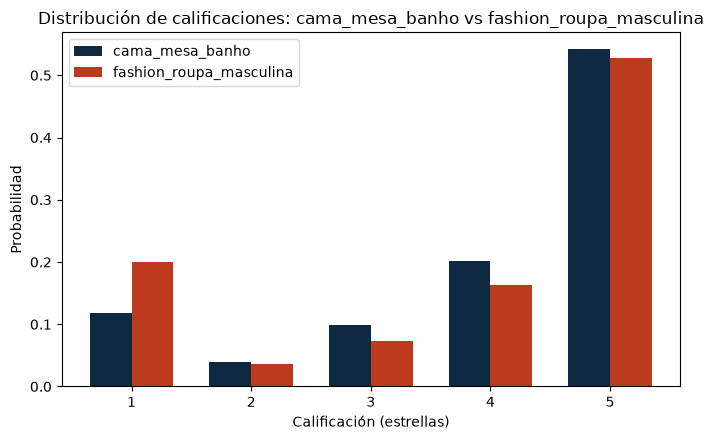

In [71]:
# ============================================================
# PASO 1: Graficar ambas distribuciones de calificación lado a lado
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.arange(1, 6)
width = 0.35

ax.bar(x - width/2, p_dist, width, label=cat_a, color="#0E2841")
ax.bar(x + width/2, q_dist, width, label=cat_b, color="#BC3A1D")

ax.set_xlabel("Calificación (estrellas)")
ax.set_ylabel("Probabilidad")
ax.set_xticks(x)
ax.set_title(f"Distribución de calificaciones: {cat_a} vs {cat_b}")
ax.legend()
plt.tight_layout()
plt.show()

**Resultado:** aunque `fashion_roupa_masculina` tiene casi el doble de 
tasa de reseñas negativas que `cama_mesa_banho` (22.86% vs. 15.75%), la 
divergencia KL entre sus distribuciones completas de calificación es 
baja (0.041-0.046 bits) — comparable al umbral que en la literatura se 
considera "poco distinguible" (KL<0.1).

**Interpretación de negocio:** la baja divergencia KL revela que, pese a 
la diferencia real en tasa de insatisfacción, la **forma general** de 
cómo se distribuyen las calificaciones es similar entre ambas categorías 
—ambas siguen dominadas por calificaciones altas (4-5 estrellas)—, y la 
diferencia se concentra específicamente en el extremo negativo (1-2 
estrellas), no en un cambio de forma global de la distribución. Esto 
sugiere que `fashion_roupa_masculina` no tiene un problema sistémico de 
insatisfacción generalizada, sino un segmento más pequeño y específico 
de experiencias negativas que valdría la pena investigar puntualmente 
(por ejemplo, revisando si hay vendedores o productos concretos dentro 
de esa categoría concentrando la mayoría de esas reseñas negativas).